In [1]:
#importação das bibliotecas

import matplotlib.pyplot as plt
import pandas            as pd
import numpy             as np

from sklearn           import ensemble          as en
from sklearn           import linear_model      as lm
from sklearn           import metrics           as mt
from sklearn           import tree              as tr

from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Separação entre Treino/ Validation/ Teste
X_train = pd.read_csv('dataset2/X_training.csv')
y_train = pd.read_csv('dataset2/y_training.csv')
X_test = pd.read_csv('dataset2/X_test.csv')
y_test = pd.read_csv('dataset2/y_test.csv')
X_validation = pd.read_csv('dataset2/X_validation.csv')
y_validation = pd.read_csv('dataset2/y_validation.csv')

## 1. KNN

In [3]:
#Ensaio sobre os dados de treinanmento n_neighbors = default = 5
model = KNeighborsClassifier()
model.fit(X_train,y_train)

yhat_train = model.predict(X_train)

acc_train = mt.accuracy_score(y_train, yhat_train)
prec_train = mt.precision_score(y_train, yhat_train)
rec_train = mt.recall_score(y_train, yhat_train)
f1_train = mt.f1_score(y_train, yhat_train)

print(f"Acurácia sobre os dados de Treino: {acc_train}")
print(f"Precisão sobre os dados de Treino: {prec_train}")
print(f"Recall sobre os dados de Treino: {rec_train}")
print(f"F1-score sobre os dados de Treino: {f1_train}")

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Acurácia sobre os dados de Treino: 0.7815624353582018
Precisão sobre os dados de Treino: 0.7558933613500558
Recall sobre os dados de Treino: 0.7325633193330788
F1-score sobre os dados de Treino: 0.744045503021685


In [4]:
values_n = [i for i in range(1,21)]
values_scores = list()

for i in values_n:
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train,y_train)
    
    #previsão sobre os dados de validação
    y_hat_val = model.predict(X_validation) 
    acc_val = mt.accuracy_score(y_validation,y_hat_val)
    
    values_scores.append(acc_val)

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: 

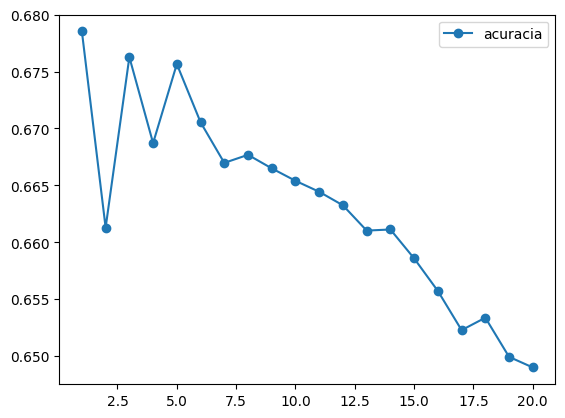

In [5]:
## Previsão sobre os dados de validacao
plt.plot(values_n ,values_scores, '-o', label='acuracia')
plt.legend()
plt.show()

In [6]:
#Ensaio sobre os dados de validação com melhor parâmetro (n_neighbors = 3)
model = KNeighborsClassifier(n_neighbors= 3)
model.fit(X_train, y_train)

y_hat_validation = model.predict(X_validation)
                            
acc_validation = mt.accuracy_score(y_validation, y_hat_validation)
pred_validation = mt.precision_score(y_validation, y_hat_validation)
rec_validation = mt.recall_score(y_validation, y_hat_validation)
f1_validation = mt.f1_score(y_validation,y_hat_validation)

print(f"Acurácia de Validação: {acc_validation}") 
print(f"Precisão de Validação: {pred_validation}") 
print(f"Recall de Validação: {rec_validation}") 
print(f"f1-score de Validação: {f1_validation}")

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Acurácia de Validação: 0.6762765854757231
Precisão de Validação: 0.6278511404561825
Recall de Validação: 0.6212784913505086
f1-score de Validação: 0.6245475239765645


In [7]:
## Modelo treinado e validado com o dataset de Treinamento
model_last = KNeighborsClassifier( n_neighbors= 3)
model_last.fit( np.concatenate( (X_train, X_validation) ), 
               np.concatenate((y_train, y_validation)) )

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [8]:
# Ensaio sobre os dados de teste com melhor parâmetro (n_neighbors = 3)
yhat_test = model_last.predict( X_test )

acc_test = mt.accuracy_score(y_test, yhat_test)
pred_test = mt.precision_score(y_test, yhat_test)
rec_test = mt.recall_score(y_test, yhat_test)
f1_test = mt.f1_score(y_test,yhat_test)

print(f"Acurácia de Teste: {acc_test}") 
print(f"Precisão de Teste: {pred_test}") 
print(f"Recall de Teste: {rec_test}") 
print(f"f1-score de Teste: {f1_test}")

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


Acurácia de Teste: 0.6884486154559147
Precisão de Teste: 0.6480251346499102
Recall de Teste: 0.6351957765068191
f1-score de Teste: 0.6415463230393246


## 2. Decision Tree Classifier

In [9]:
#Ensaio sobre os dados de Treino
model = tr.DecisionTreeClassifier() 
model.fit(X_train, y_train)

yhat_train = model.predict(X_train)

acc_train = mt.accuracy_score(y_train, yhat_train)
prec_train = mt.precision_score(y_train, yhat_train)
rec_train = mt.recall_score(y_train, yhat_train)
f1_train = mt.f1_score(y_train, yhat_train)

print(f"Acurácia sobre os dados de Treino: {acc_train}")
print(f"Precisão sobre os dados de Treino: {prec_train}")
print(f"Recall sobre os dados de Treino: {rec_train}")
print(f"F1-score sobre os dados de Treino: {f1_train}")

Acurácia sobre os dados de Treino: 1.0
Precisão sobre os dados de Treino: 1.0
Recall sobre os dados de Treino: 1.0
F1-score sobre os dados de Treino: 1.0


In [10]:
#Modelo treinado e validado com o dataset de treinamento
values = [i for i in range(1,60)]
val_scores = list()

for i in values:
    model = tr.DecisionTreeClassifier(max_depth=i)
    model.fit(X_train,y_train)
    
    #Previsão sobre os dados de validação
    yhat_val = model.predict(X_validation)
    acc_val = mt.accuracy_score(y_validation,yhat_val)
    
    val_scores.append(acc_val)

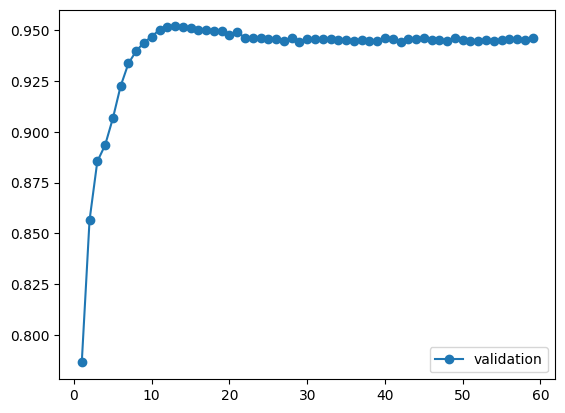

In [11]:
#plot of train and test scores vs tree depth
plt.plot(values, val_scores, '-o', label = 'validation')
plt.legend()
plt.show()

In [12]:
# Ensaio sobre os dados de Validação com o melhor parâmetro (max_depth = 14)
model = tr.DecisionTreeClassifier(max_depth=14)
model.fit(X_train,y_train)

yhat_val = model.predict(X_validation)

acc_val = mt.accuracy_score(y_validation,yhat_val)
prec_val = mt.precision_score(y_validation,yhat_val)
rec_val = mt.recall_score(y_validation,yhat_val)
f1_val = mt.f1_score(y_validation,yhat_val)


print(f"Acurácia sobre os dados de Validação: {acc_val}")
print(f"Precisão sobre os dados de Validação: {prec_val}")
print(f"Recall sobre os dados de Validação: {rec_val}")
print(f"F1-score sobre os dados de Validação: {f1_val}")

Acurácia sobre os dados de Validação: 0.9522185398500596
Precisão sobre os dados de Validação: 0.95580404685836
Recall sobre os dados de Validação: 0.9328829163263791
F1-score sobre os dados de Validação: 0.9442043960172835


In [13]:
## Modelo treinado e validado com o dataset de Treinamento
model_last = tr.DecisionTreeClassifier( max_depth=14 )
model_last.fit( np.concatenate( (X_train, X_validation) ), np.concatenate((y_train, y_validation)) )

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [14]:
# Ensaio sobre os dados de Validação com o melhor parâmetro (max_depth = 14)
yhat_test = model_last.predict( X_test )

acc_test = mt.accuracy_score(y_test,yhat_test)
prec_test = mt.precision_score(y_test,yhat_test)
rec_test = mt.recall_score(y_test,yhat_test)
f1_test = mt.f1_score(y_test,yhat_test)


print(f"Acurácia sobre os dados de teste: {acc_test}")
print(f"Precisão sobre os dados de teste: {prec_test}")
print(f"Recall sobre os dados de teste: {rec_test}")
print(f"F1-score sobre os dados de teste: {f1_test}")


Acurácia sobre os dados de teste: 0.9561271386088904
Precisão sobre os dados de teste: 0.9565295010265108
Recall sobre os dados de teste: 0.9428948526176859
F1-score sobre os dados de teste: 0.9496632399858206


c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


## 3. Random Forest Classifier

In [15]:
#Ensaio sobre os dados de Treino
model = en.RandomForestClassifier(random_state=0)
model.fit(X_train, np.ravel(y_train))

yhat_train = model.predict(X_train)

In [16]:
#Ensaio sobre os dados de Treino

acc_train = mt.accuracy_score(y_train, yhat_train)
prec_train = mt.precision_score(y_train, yhat_train)
rec_train = mt.recall_score(y_train, yhat_train)
f1_train = mt.f1_score(y_train, yhat_train)

print(f"Acurácia sobre os dados de Treino: {acc_train}")
print(f"Precisão sobre os dados de Treino: {prec_train}")
print(f"Recall sobre os dados de Treino: {rec_train}")
print(f"F1-score sobre os dados de Treino: {f1_train}")

Acurácia sobre os dados de Treino: 1.0
Precisão sobre os dados de Treino: 1.0
Recall sobre os dados de Treino: 1.0
F1-score sobre os dados de Treino: 1.0


In [17]:
#Busca de hiperparâmetro (n_estimators) usando os dados de validação
values_n_estimators = [10, 25, 50, 75, 100, 150, 200]
val_scores = list()

for i in values_n_estimators:
    model = en.RandomForestClassifier(n_estimators=i, random_state=0)
    model.fit(X_train, np.ravel(y_train))

    #Previsão sobre os dados de validação
    yhat_val = model.predict(X_validation)
    acc_val = mt.accuracy_score(y_validation, yhat_val)

    val_scores.append(acc_val)

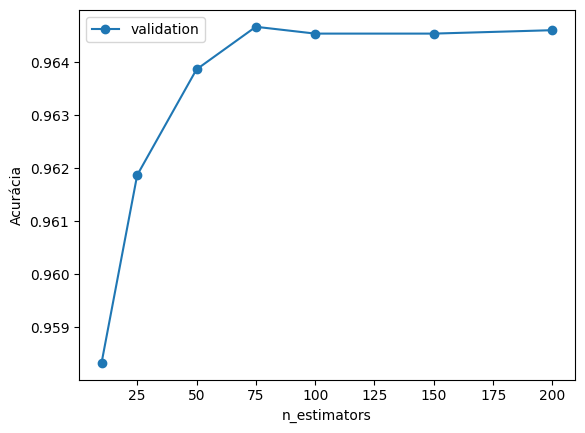

In [18]:
#plot of validation accuracy vs n_estimators
plt.plot(values_n_estimators, val_scores, '-o', label='validation')
plt.xlabel('n_estimators')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

In [19]:
# Ensaio sobre os dados de Validação com o melhor parâmetro (n_estimators = 100)
model = en.RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, np.ravel(y_train))

yhat_val = model.predict(X_validation)

In [20]:
#Ensaio sobre os dados de Validação

acc_val = mt.accuracy_score(y_validation, yhat_val)
prec_val = mt.precision_score(y_validation, yhat_val)
rec_val = mt.recall_score(y_validation, yhat_val)
f1_val = mt.f1_score(y_validation, yhat_val)

print(f"Acurácia sobre os dados de Validação: {acc_val}")
print(f"Precisão sobre os dados de Validação: {prec_val}")
print(f"Recall sobre os dados de Validação: {rec_val}")
print(f"F1-score sobre os dados de Validação: {f1_val}")

Acurácia sobre os dados de Validação: 0.9645419736799768
Precisão sobre os dados de Validação: 0.9737951114857099
Recall sobre os dados de Validação: 0.9435741331947435
F1-score sobre os dados de Validação: 0.9584464555052791


In [21]:
## Modelo treinado e validado com o dataset de Treinamento + Validação
model_last = en.RandomForestClassifier(n_estimators=100, random_state=0)
model_last.fit(np.concatenate((X_train, X_validation)),
               np.ravel(np.concatenate((y_train, y_validation))))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
# Ensaio sobre os dados de teste com o melhor parâmetro (n_estimators = 100)
yhat_test = model_last.predict(X_test)

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [23]:
#Ensaio sobre os dados de teste

acc_test = mt.accuracy_score(y_test, yhat_test)
prec_test = mt.precision_score(y_test, yhat_test)
rec_test = mt.recall_score(y_test, yhat_test)
f1_test = mt.f1_score(y_test, yhat_test)

print(f"Acurácia sobre os dados de teste: {acc_test}")
print(f"Precisão sobre os dados de teste: {prec_test}")
print(f"Recall sobre os dados de teste: {rec_test}")
print(f"F1-score sobre os dados de teste: {f1_test}")

Acurácia sobre os dados de teste: 0.9646236434557602
Precisão sobre os dados de teste: 0.9736197987489802
Recall sobre os dados de teste: 0.945006599208095
F1-score sobre os dados de teste: 0.9590998392570101


## 4. Logistic Regression

In [24]:
#Ensaio sobre os dados de Treino
model = lm.LogisticRegression(max_iter=3000)
model.fit(X_train, np.ravel(y_train))

yhat_train = model.predict(X_train)

In [25]:
#Ensaio sobre os dados de Treino

acc_train = mt.accuracy_score(y_train, yhat_train)
prec_train = mt.precision_score(y_train, yhat_train)
rec_train = mt.recall_score(y_train, yhat_train)
f1_train = mt.f1_score(y_train, yhat_train)

print(f"Acurácia sobre os dados de Treino: {acc_train}")
print(f"Precisão sobre os dados de Treino: {prec_train}")
print(f"Recall sobre os dados de Treino: {rec_train}")
print(f"F1-score sobre os dados de Treino: {f1_train}")

Acurácia sobre os dados de Treino: 0.8762462938702338
Precisão sobre os dados de Treino: 0.8716565148305084
Recall sobre os dados de Treino: 0.837819778541428
F1-score sobre os dados de Treino: 0.8544032708157571


In [26]:
#Busca de hiperparâmetro (C) usando os dados de validação
values_C = [0.001, 0.01, 0.1, 1, 10, 100]
val_scores = list()

for i in values_C:
    model = lm.LogisticRegression(C=i, max_iter=3000)
    model.fit(X_train, np.ravel(y_train))

    #Previsão sobre os dados de validação
    yhat_val = model.predict(X_validation)
    acc_val = mt.accuracy_score(y_validation, yhat_val)

    val_scores.append(acc_val)

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://s

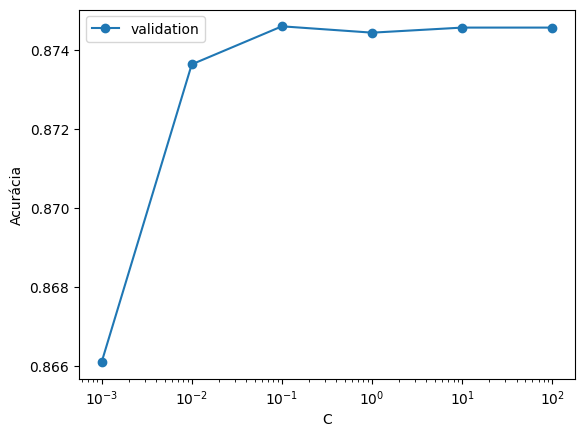

In [27]:
#plot of validation accuracy vs C
plt.plot(values_C, val_scores, '-o', label='validation')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

In [28]:
# Ensaio sobre os dados de Validação com o melhor parâmetro (C = 1)
model = lm.LogisticRegression(C=1, max_iter=3000)
model.fit(X_train, np.ravel(y_train))

yhat_val = model.predict(X_validation)

In [29]:
#Ensaio sobre os dados de Validação

acc_val = mt.accuracy_score(y_validation, yhat_val)
prec_val = mt.precision_score(y_validation, yhat_val)
rec_val = mt.recall_score(y_validation, yhat_val)
f1_val = mt.f1_score(y_validation, yhat_val)

print(f"Acurácia sobre os dados de Validação: {acc_val}")
print(f"Precisão sobre os dados de Validação: {prec_val}")
print(f"Recall sobre os dados de Validação: {rec_val}")
print(f"F1-score sobre os dados de Validação: {f1_val}")

Acurácia sobre os dados de Validação: 0.8744489848450723
Precisão sobre os dados de Validação: 0.8690118028234205
Recall sobre os dados de Validação: 0.8363649862647561
F1-score sobre os dados de Validação: 0.8523759079903148


In [30]:
## Modelo treinado e validado com o dataset de Treinamento + Validação
model_last = lm.LogisticRegression(C=1, max_iter=3000)
model_last.fit(np.concatenate((X_train, X_validation)),
               np.ravel(np.concatenate((y_train, y_validation))))

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [31]:
# Ensaio sobre os dados de teste com o melhor parâmetro (C = 1)
yhat_test = model_last.predict(X_test)

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [32]:
#Ensaio sobre os dados de teste

acc_test = mt.accuracy_score(y_test, yhat_test)
prec_test = mt.precision_score(y_test, yhat_test)
rec_test = mt.recall_score(y_test, yhat_test)
f1_test = mt.f1_score(y_test, yhat_test)

print(f"Acurácia sobre os dados de teste: {acc_test}")
print(f"Precisão sobre os dados de teste: {prec_test}")
print(f"Recall sobre os dados de teste: {rec_test}")
print(f"F1-score sobre os dados de teste: {f1_test}")

Acurácia sobre os dados de teste: 0.871084849187039
Precisão sobre os dados de teste: 0.8673684210526316
Recall sobre os dados de teste: 0.8337879454465464
F1-score sobre os dados de teste: 0.8502467474203679


## Tabela resumo - todos os algoritmos (dados de teste)

In [35]:
#Tabela resumo consolidada - dados de teste

resumo_teste = pd.DataFrame({
    'Algoritmo': ['KNN','Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [0.6884, 0.9561, 0.9646, 0.8706],
    'Precision': [0.6480, 0.9565, 0.9736, 0.8664],
    'Recall': [0.6351, 0.9428, 0.9450, 0.8338],
    'F1-Score': [0.6415, 0.9496, 0.9591, 0.8498]
})
resumo_teste

,Algoritmo,Accuracy,Precision,Recall,F1-Score
0,KNN,0.6884,0.6480,0.6351,0.6415
1,Decision Tree,0.9561,0.9565,0.9428,0.9496
2,Random Forest,0.9646,0.9736,0.9450,0.9591
3,Logistic Regression,0.8706,0.8664,0.8338,0.8498
